In [1]:
import json

In [2]:
import pickle

In [3]:
import pandas as pd

In [4]:
with open("preds_wo_features_scores.pkl", "rb") as f:
    preds_wo_features_scores = pickle.load(f)

In [5]:
preds_wo_features_scores.head()

,user_name,item_title,is_valid
0,ai_and_nlp_developer,Цифровой универсальный комментарий,1
1,ai_and_nlp_developer,"Учебный ассистент по курсу "" Бухгалтерский учет""",1
2,ai_and_nlp_developer,Мультиагентная интеллектуальная обучающая сист...,1
3,ai_and_nlp_developer,Разработка чат-бота для выбора пептидов для се...,1
4,ai_and_nlp_developer,Интеллектуальный помощник по обработке лекций ...,1


In [6]:
with open("preds_w_features_scores.pkl", "rb") as f:
    preds_w_features_scores = pickle.load(f)

In [7]:
preds_w_features_scores.head()

,user_name,item_title,is_valid
0,ai_and_nlp_developer,Цифровой универсальный комментарий,1
1,ai_and_nlp_developer,Мультиагентная интеллектуальная обучающая сист...,1
2,ai_and_nlp_developer,"Учебный ассистент по курсу "" Бухгалтерский учет""",1
3,ai_and_nlp_developer,Разработка чат-бота для выбора пептидов для се...,1
4,ai_and_nlp_developer,Разработка MVP платформы для ИИ-персонализации...,1


In [8]:
pwofg = (
    preds_wo_features_scores.groupby(by=["user_name"])
    .agg({"is_valid": "mean"})
    .reset_index(drop=False)
)
pwofg.columns = ["user_name", "mean_score"]
pwofg = pwofg.sort_values(by=["mean_score"], ascending=False).reset_index(drop=True)

In [9]:
pwofg.head()

,user_name,mean_score
0,strategic_management_consultant_and_leader,1.0
1,regional_studies_and_geopolitics_expert,1.0
2,media_and_communications_specialist,1.0
3,media_and_communication_strategist,1.0
4,international_relations_and_geopolitics_expert,1.0


In [10]:
pwfg = (
    preds_w_features_scores.groupby(by=["user_name"])
    .agg({"is_valid": "mean"})
    .reset_index(drop=False)
)
pwfg.columns = ["user_name", "mean_score"]
pwfg = pwfg.sort_values(by=["mean_score"], ascending=False).reset_index(drop=True)

In [11]:
pwfg.head()

,user_name,mean_score
0,strategic_management_consultant_and_leader,1.0
1,geopolitics_and_international_relations_expert,1.0
2,multilingual_linguistics_researcher,1.0
3,media_journalism_and_cultural_studies_expert,1.0
4,media_and_culture_strategist,1.0


In [12]:
final = pwofg.merge(pwfg, on=["user_name"])
final["diff"] = final["mean_score_y"] - final["mean_score_x"]

In [13]:
final.to_excel("llm_as_a_judge.xlsx", index=False)

In [14]:
with open("artificial_profiles_scores.pkl", "rb") as f:
    artificial_profiles_scores = pickle.load(f)

In [15]:
with open("titles_with_tags_dict.pkl", "rb") as f:
    titles_with_tags_dict = pickle.load(f)

In [16]:
data = []

for profile_name, scores in artificial_profiles_scores.items():
    for title, score in scores.items():
        title = json.loads(title)["title"]
        tags = titles_with_tags_dict.get(title, [])
        data.append(
            {
                "profile_name": profile_name,
                "title": title,
                "score": score,
                "tags": tags,
            }
        )

df = pd.DataFrame(data)

In [17]:
df.head()

,profile_name,title,score,tags
0,global_economics_and_geopolitics_analyst,Исследование приоритетов и механизмов реализац...,5,"[international_relations, political_economics,..."
1,global_economics_and_geopolitics_analyst,Сеть военно-политических союзов в Евразии: баз...,4,"[geopolitics, international_relations, databas..."
2,global_economics_and_geopolitics_analyst,Ежемесячный мониторинг мировой экономики и гео...,5,"[economics, geopolitics, risk_management, macr..."
3,global_economics_and_geopolitics_analyst,Запуск регулярного подкаста НИУ ВШЭ о странах ...,2,"[media_production, podcast, international_rela..."
4,global_economics_and_geopolitics_analyst,"Студенческий клуб ""Говорим об Эфиопии""",3,"[sociology, international_relations, culture, ..."


In [18]:
df_exploded = df.explode("tags").reset_index(drop=True)

In [19]:
sorted(df_exploded.profile_name.unique())

['ai_and_nlp_developer',
 'ai_policy_and_social_impact_analyst',
 'cultural_and_media_anthropologist',
 'cultural_humanities_researcher_media_studies',
 'data_driven_policy_analyst',
 'digital_marketing_and_media_strategy',
 'digital_platform_developer_and_educator',
 'education_and_cultural_development_expert',
 'educational_psychologist_and_methodologist',
 'educational_tech_developer',
 'financial_economist_and_analyst',
 'geopolitics_and_international_relations_expert',
 'global_economics_and_geopolitics_analyst',
 'historical_culture_researcher_media_specialist',
 'international_relations_and_geopolitics_expert',
 'legal_policy_and_ethics_researcher',
 'literary_and_cultural_analyst_cross_cultural',
 'media_and_communication_strategist',
 'media_and_communications_specialist',
 'media_and_culture_strategist',
 'media_journalism_and_cultural_studies_expert',
 'multidisciplinary_tech_and_language_developer',
 'multilingual_linguistics_researcher',
 'multilingual_nlp_and_ai_specialis

In [20]:
import squarify
from matplotlib import pyplot as plt
import seaborn as sns

<Axes: xlabel='score', ylabel='profile_name'>

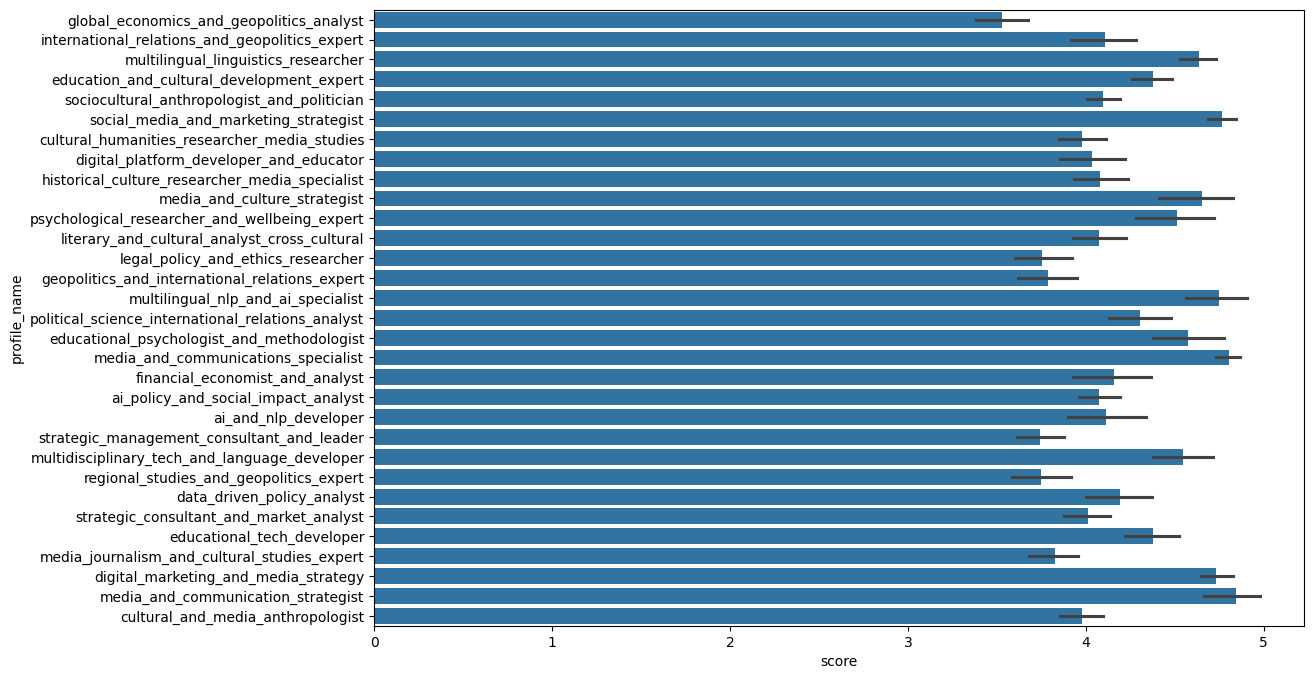

In [21]:
fig = plt.figure(figsize=(12, 8))

sns.barplot(data=df, x="score", y="profile_name", orient="h")

In [22]:
df_score = df_exploded.groupby(by=["profile_name"]).agg({"score": "median"}).reset_index(drop=False)
df_score.columns = ["profile_name", "score"]
df_score = df_score.sort_values(by=["score"], ascending=False).reset_index(drop=True)

<Axes: xlabel='score', ylabel='profile_name'>

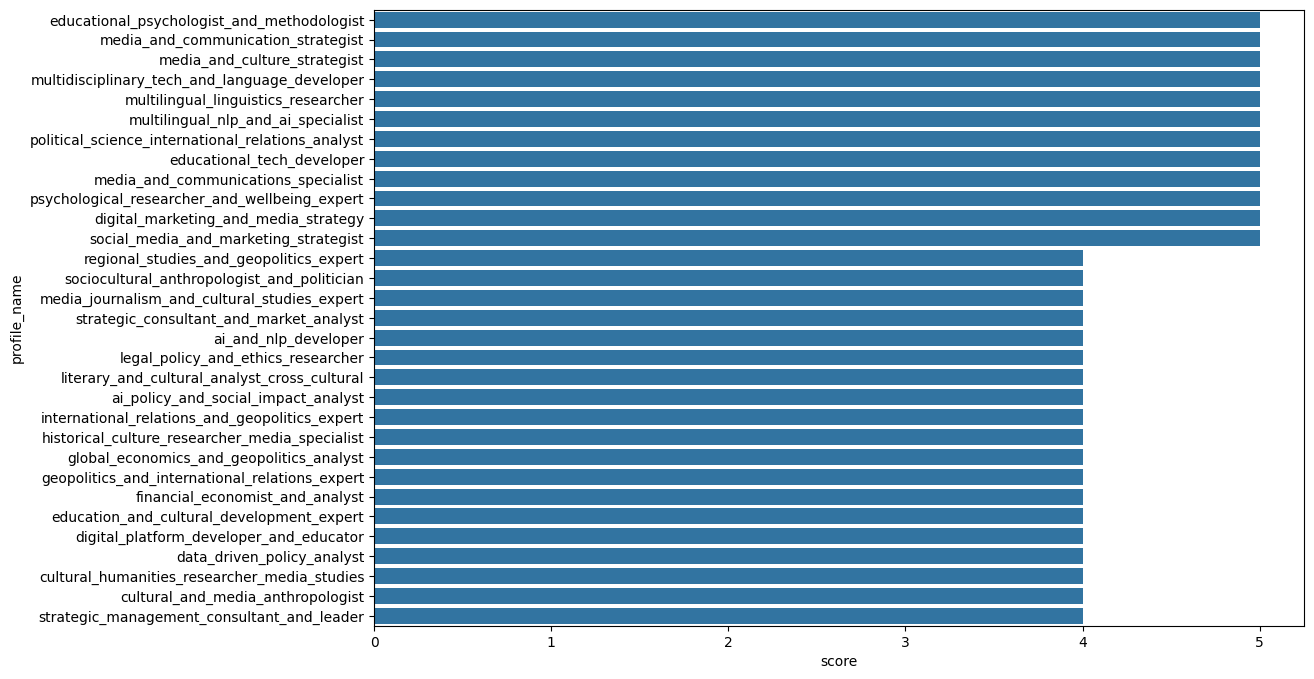

In [23]:
fig = plt.figure(figsize=(12, 8))

sns.barplot(data=df_score, x="score", y="profile_name", orient="h")

In [24]:
df_exploded_tags = df_exploded[(df_exploded["profile_name"] == "global_economics_and_geopolitics_analyst") & (df_exploded["score"] == 5)].groupby(by=["tags"]).agg({"score": ["count", "median"]}).reset_index(drop=False)
df_exploded_tags.columns = ["tags", "count", "score"]
df_exploded_tags = df_exploded_tags.sort_values(by=["count"], ascending=False).reset_index(drop=True)
df_exploded_tags = df_exploded_tags[df_exploded_tags["count"] > 1].reset_index(drop=True)

In [25]:
df_exploded_tags.head()

,tags,count,score
0,geopolitics,27,5.0
1,international_relations,23,5.0
2,economics,19,5.0
3,political_science,9,5.0
4,regional_studies,6,5.0


In [26]:
df_exploded_tags.tail()

,tags,count,score
30,time_series,2,5.0
31,bilateral_relations,2,5.0
32,brics,2,5.0
33,technology_sector,2,5.0
34,data_analysis,2,5.0


<Axes: >

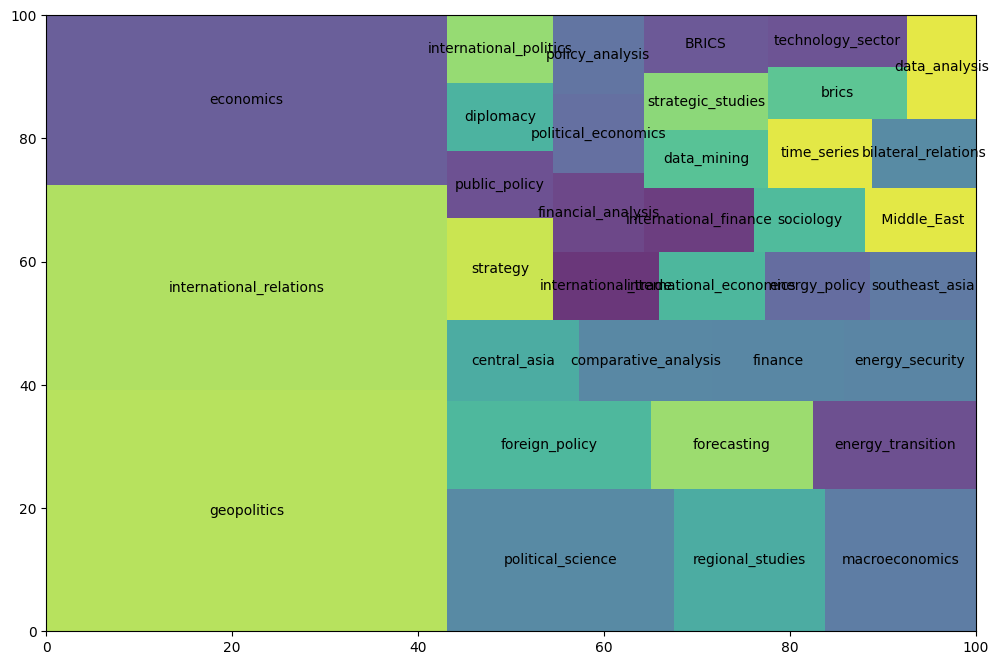

In [27]:
fig = plt.figure(figsize=(12, 8))

squarify.plot(sizes=df_exploded_tags["count"], label=df_exploded_tags["tags"], alpha=0.8)

In [28]:
df_exploded_profiles = df_exploded[(df_exploded["tags"] == "economics") & (df_exploded["score"] == 5)].groupby(by=["profile_name"]).agg({"score": ["count", "median"]}).reset_index(drop=False)
df_exploded_profiles.columns = ["profile_name", "count", "score"]
df_exploded_profiles = df_exploded_profiles.sort_values(by=["count"], ascending=False).reset_index(drop=True)
df_exploded_profiles = df_exploded_profiles[df_exploded_profiles["count"] > 1].reset_index(drop=True)

In [29]:
df_exploded_profiles.head

<bound method NDFrame.head of                                          profile_name  count  score
0             strategic_consultant_and_market_analyst     32    5.0
1                          data_driven_policy_analyst     24    5.0
2            global_economics_and_geopolitics_analyst     19    5.0
3                     financial_economist_and_analyst     18    5.0
4   political_science_international_relations_analyst     13    5.0
5             regional_studies_and_geopolitics_expert     12    5.0
6         sociocultural_anthropologist_and_politician     11    5.0
7      geopolitics_and_international_relations_expert     11    5.0
8          strategic_management_consultant_and_leader     10    5.0
9      international_relations_and_geopolitics_expert      9    5.0
10                ai_policy_and_social_impact_analyst      5    5.0
11                 legal_policy_and_ethics_researcher      3    5.0
12                  cultural_and_media_anthropologist      2    5.0>

<Axes: >

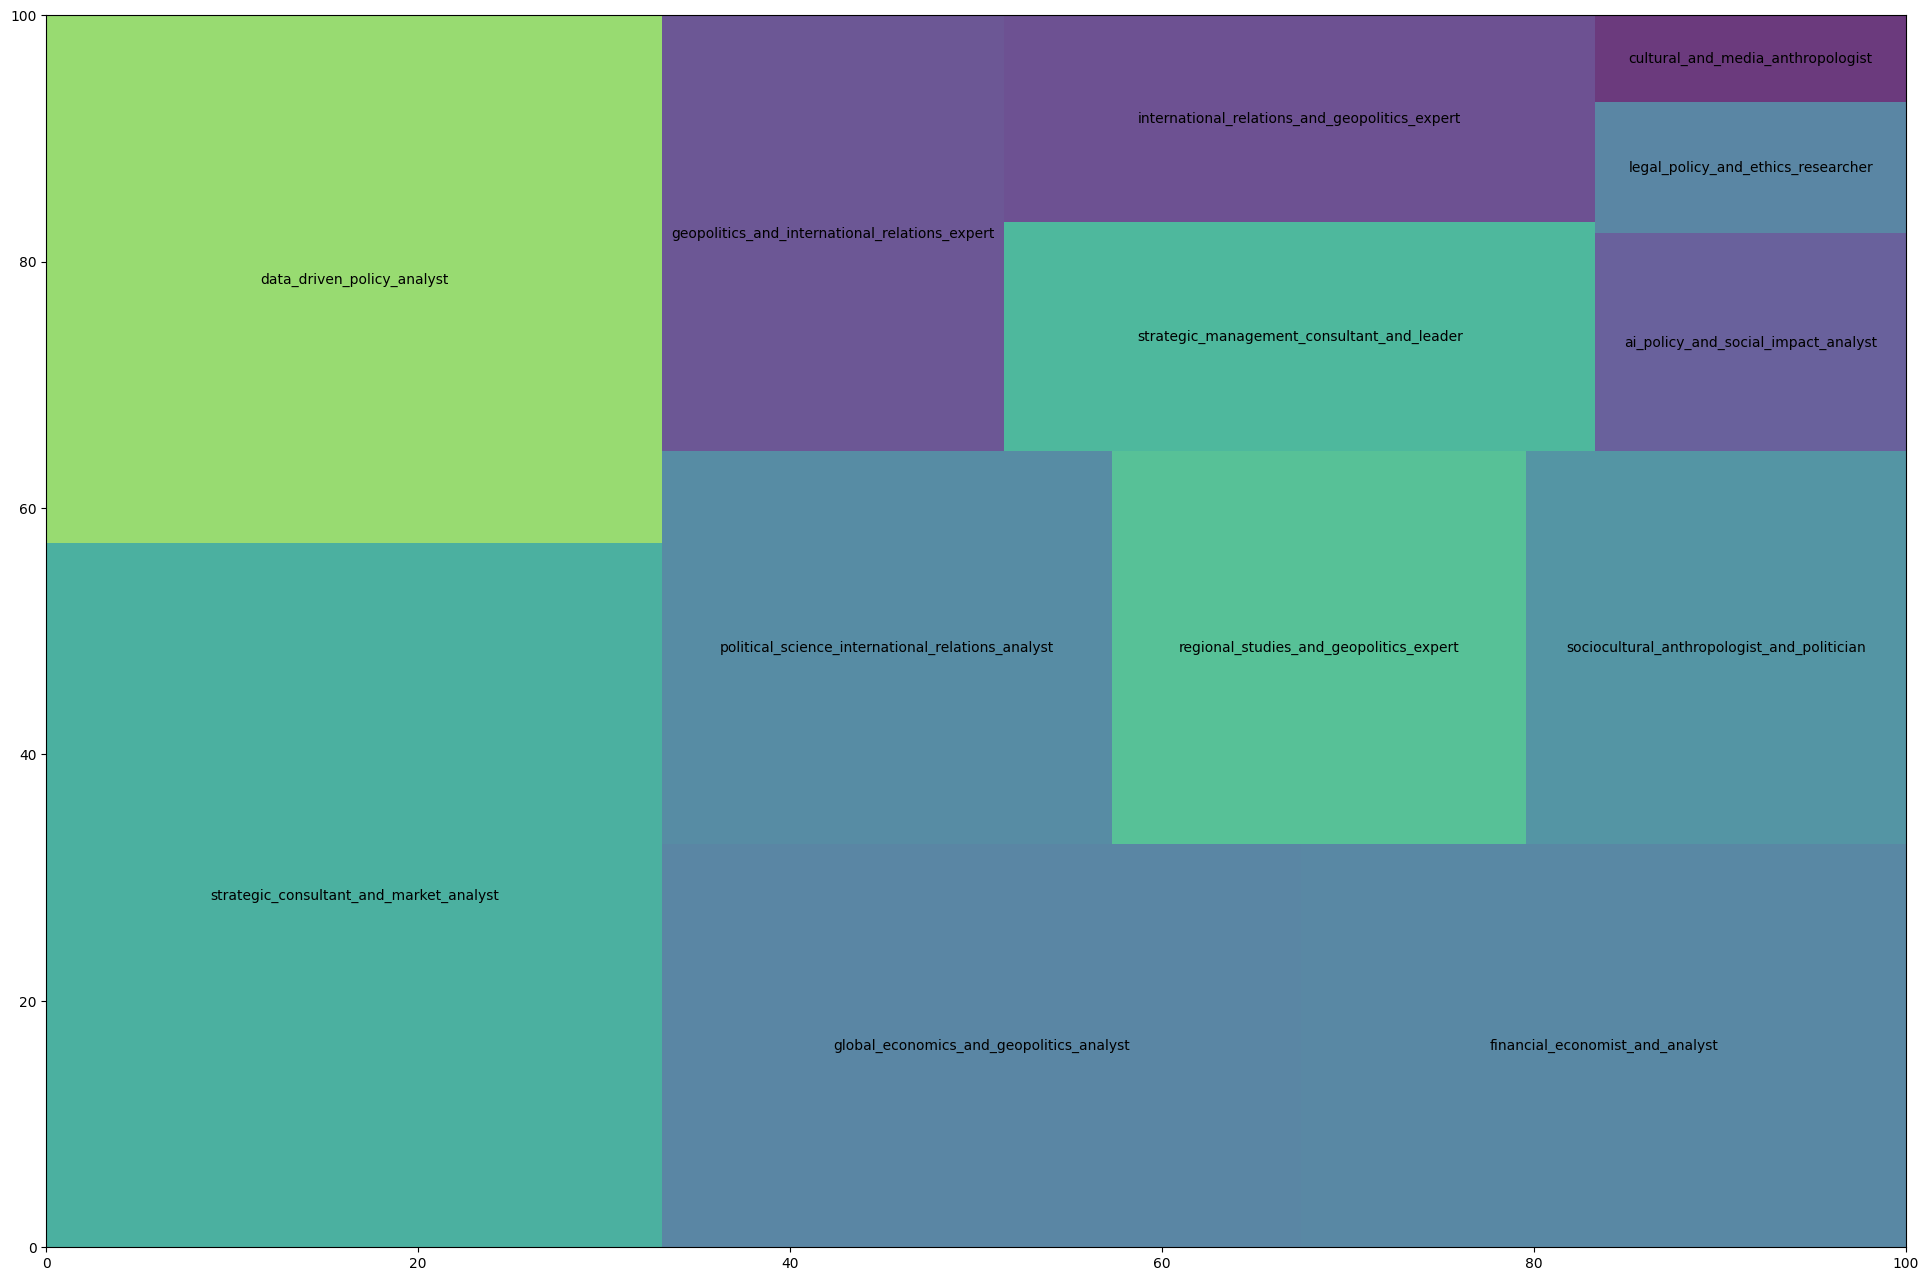

In [30]:
fig = plt.figure(figsize=(24, 16))

squarify.plot(sizes=df_exploded_profiles["count"], label=df_exploded_profiles["profile_name"], alpha=0.8)

In [31]:
data = []

for title in titles_with_tags_dict.keys():
    tags = titles_with_tags_dict[title]
    data.append({"title": title, "tags": tags})

df = pd.DataFrame(data)

In [32]:
df.head()

,title,tags
0,Исследование приоритетов и механизмов реализац...,"[international_relations, political_economics,..."
1,Антрополе - научно-популярный видео-подкаст о ...,"[anthropology, social_phenomena, media, podcas..."
2,"Разработка, создание и ведение сайта, посвящен...","[web_development, history, cultural_studies, d..."
3,Перевод с английского языка коллективной моног...,"[criminology, literature_review, translation, ..."
4,Сеть военно-политических союзов в Евразии: баз...,"[geopolitics, international_relations, databas..."


In [33]:
df = df.explode("tags").reset_index(drop=True)

In [34]:
dfg = df.groupby(by=["tags"]).agg({"title": "count"}).reset_index(drop=False).sort_values(by=["title"], ascending=False).reset_index(drop=True).head(32)

<Axes: >

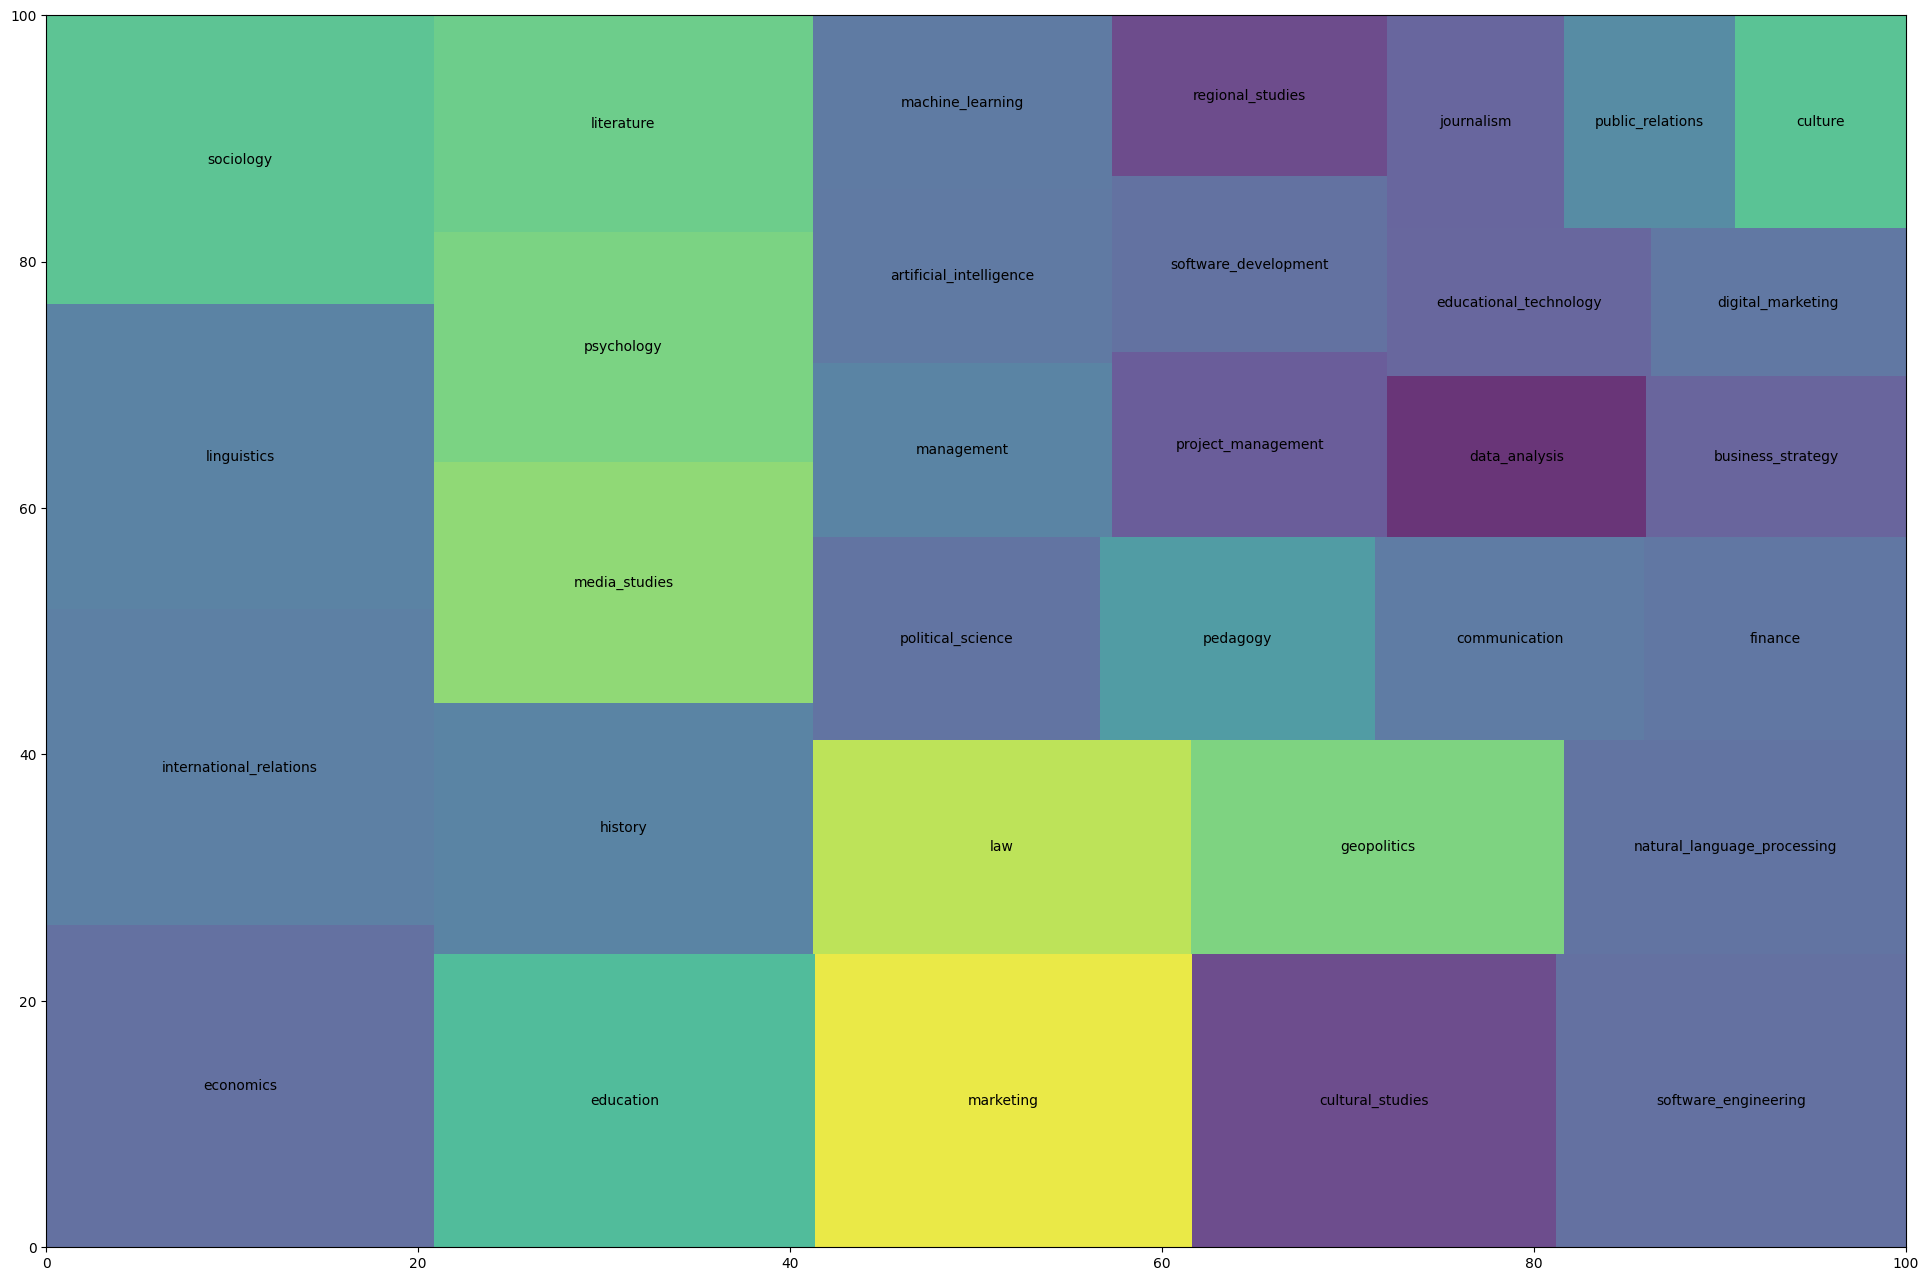

In [35]:
fig = plt.figure(figsize=(24, 16))

squarify.plot(sizes=dfg["title"], label=dfg["tags"], alpha=0.8)

In [36]:
dfg.to_excel("tags_distribution.xlsx", index=False)